  STEP 4: AI/ML MODEL TRAINING & EVALUATION
  AI-Enabled IoT Smart Energy Monitoring System

📂 [1/6] Loading preprocessed dataset...
   ✅ Dataset loaded: 5000 rows × 16 columns

   📋 Columns found:
      1. Voltage
      2. Current
      3. Power
      4. Relay_1
      5. Relay_2
      6. Battery_Level
      7. Hour_of_Day
      8. Load_Type
      9. Is_Anomaly
      10. Predicted_Power_Next
      11. Is_Daytime
      12. Power_Delta
      13. Current_Delta
      14. Voltage_Delta
      15. Power_Rolling_Mean
      16. Current_Rolling_Std

   📊 Quick Data Health Check:
      • Missing values: 0
      • Voltage range:  151.1V – 236.6V
      • Current range:  -5.00A – 24.85A
      • Power range:    -1166.8W – 4205.0W
      • Battery range:  92.0% – 100.0%
      • Load Types:     [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
      • Anomalies:      50 out of 5000 (1.00%)

🔧 [2/6] Defining features and targets...
   ✅ Features defined: 13 input features
   ✅ Targets defined: Load_Ty

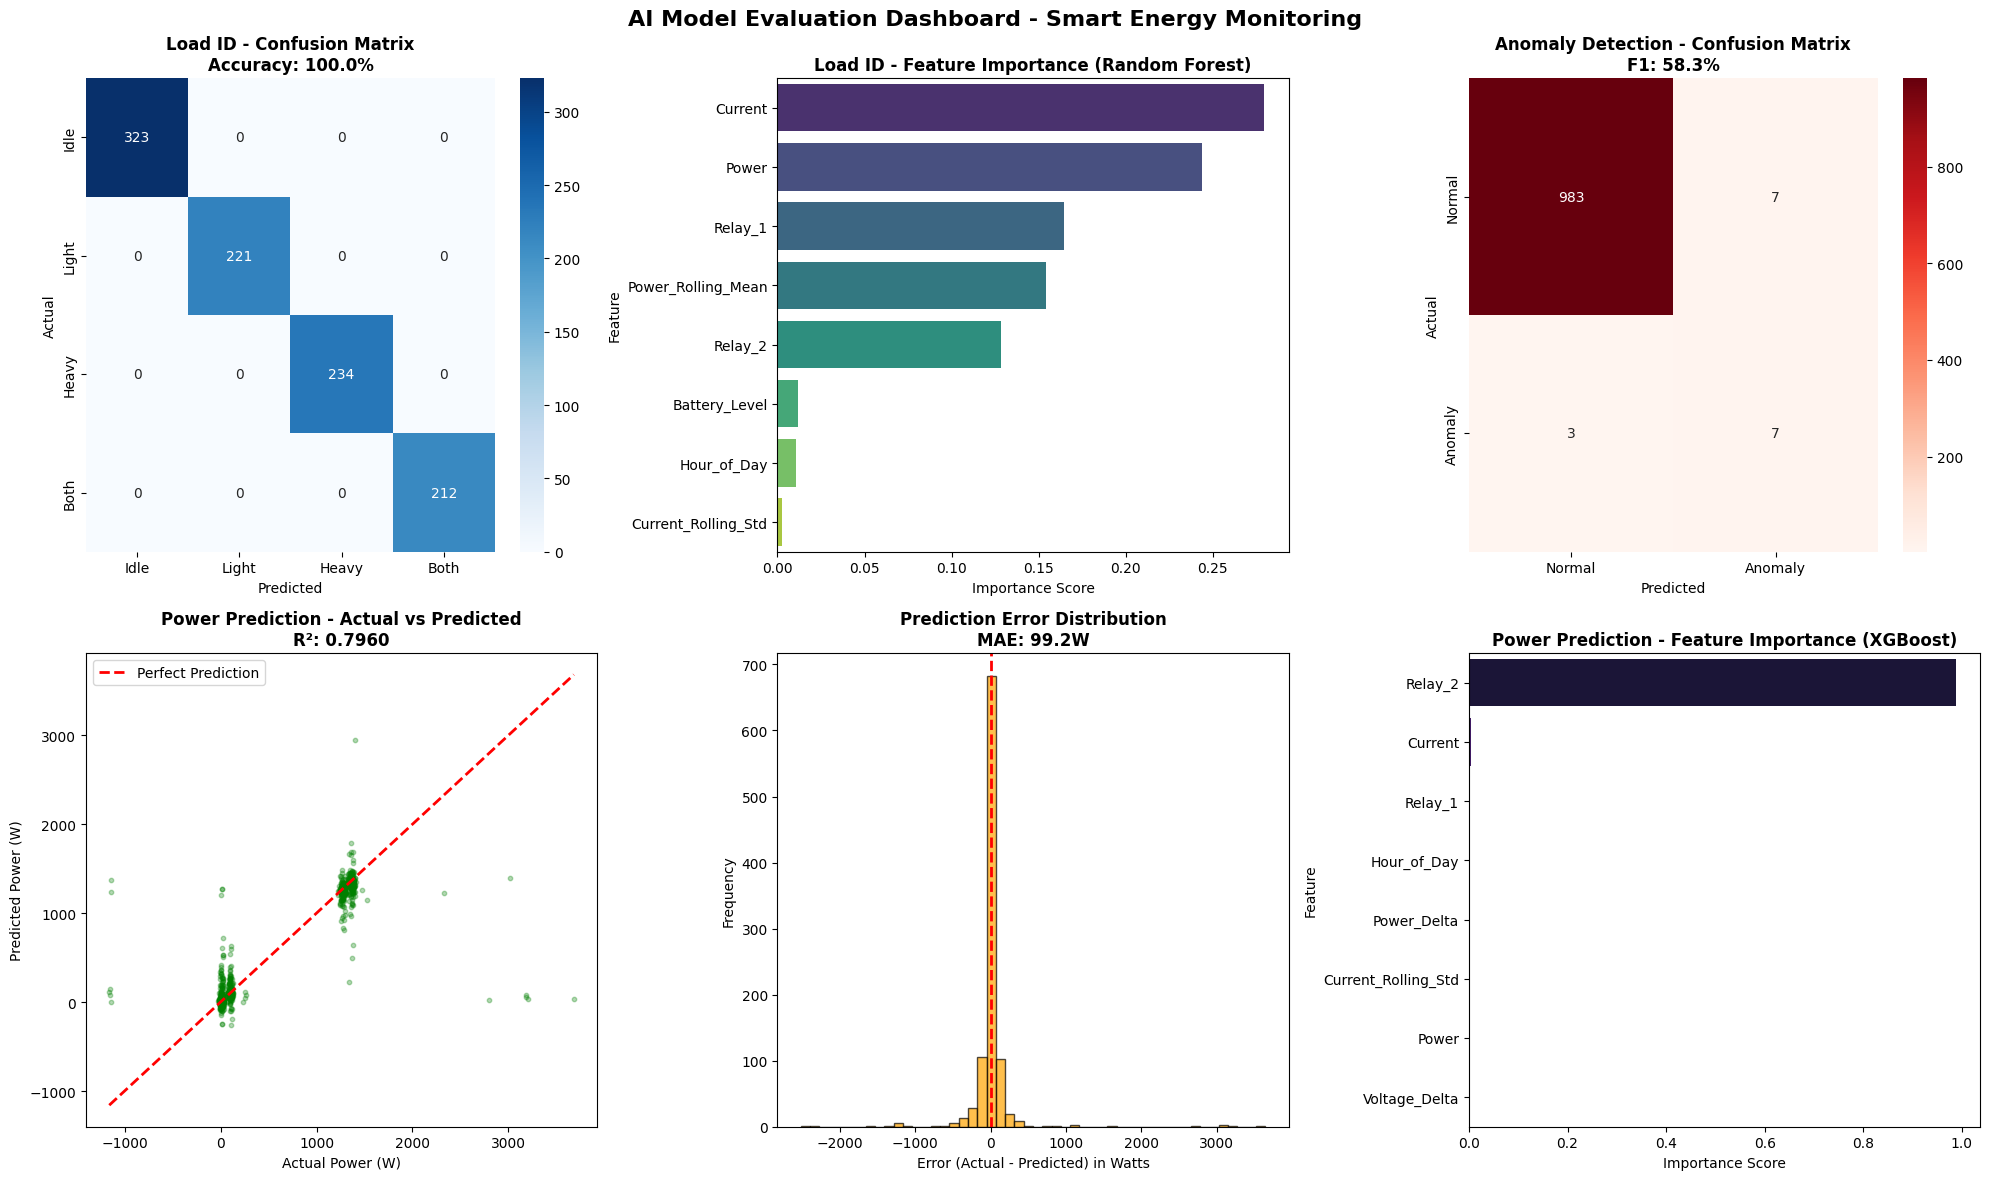


✅ Dashboard saved as 'model_evaluation_dashboard.png'

  🏆 FINAL MODEL SUMMARY

  ┌─────────────────────┬────────────────────┬──────────────┐
  │ Model               │ Algorithm          │ Key Metric   │
  ├─────────────────────┼────────────────────┼──────────────┤
  │ Load Identification │ Random Forest      │ Acc: 100.0%   │
  │ Anomaly Detection   │ Isolation Forest   │ F1:  58.3%    │
  │ Power Prediction    │ XGBoost Regressor  │ R²:  0.7960   │
  └─────────────────────┴────────────────────┴──────────────┘
  
  💾 Saved Files:
     • model_load_id_rf.pkl    + scaler_load.pkl
     • model_anomaly_iso.pkl   + scaler_anomaly.pkl
     • model_power_xgb.pkl     + scaler_power.pkl
     • model_evaluation_dashboard.png

🚀 All models trained and ready for Step 5: Deployment & API!


In [3]:
# ============================================================
# STEP 4: MODEL TRAINING, EVALUATION & SELECTION
# AI-Enabled IoT Smart Energy Monitoring System
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBRegressor
import joblib

print("=" * 65)
print("  STEP 4: AI/ML MODEL TRAINING & EVALUATION")
print("  AI-Enabled IoT Smart Energy Monitoring System")
print("=" * 65)

# ============================================================
# 1. LOAD & INSPECT THE PREPROCESSED DATASET
# ============================================================
print("\n📂 [1/6] Loading preprocessed dataset...")

df = pd.read_csv('esp32_solar_energy_dataset_ehanced.csv')
print(f"   ✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# Display column names so we know exactly what we're working with
print(f"\n   📋 Columns found:")
for i, col in enumerate(df.columns):
    print(f"      {i+1}. {col}")

# Quick statistical check
print(f"\n   📊 Quick Data Health Check:")
print(f"      • Missing values: {df.isnull().sum().sum()}")
print(f"      • Voltage range:  {df['Voltage'].min():.1f}V – {df['Voltage'].max():.1f}V")
print(f"      • Current range:  {df['Current'].min():.2f}A – {df['Current'].max():.2f}A")
print(f"      • Power range:    {df['Power'].min():.1f}W – {df['Power'].max():.1f}W")
print(f"      • Battery range:  {df['Battery_Level'].min():.1f}% – {df['Battery_Level'].max():.1f}%")
print(f"      • Load Types:     {sorted(df['Load_Type'].unique())}")
print(f"      • Anomalies:      {df['Is_Anomaly'].sum()} out of {len(df)} ({(df['Is_Anomaly'].sum()/len(df))*100:.2f}%)")

# ============================================================
# 2. DEFINE FEATURES (X) AND TARGETS (y)
# ============================================================
print("\n🔧 [2/6] Defining features and targets...")

# These are the INPUT features the AI will analyze
# (Everything the ESP32 sensors + engineered features provide)
feature_cols = [
    'Voltage', 'Current', 'Power',
    'Relay_1', 'Relay_2',
    'Battery_Level', 'Hour_of_Day', 'Is_Daytime',
    'Power_Delta', 'Current_Delta', 'Voltage_Delta',
    'Power_Rolling_Mean', 'Current_Rolling_Std'
]

X = df[feature_cols]

# Three separate targets for three separate AI goals
y_load = df['Load_Type']               # Classification target
y_anomaly = df['Is_Anomaly']           # Anomaly detection target
y_power = df['Predicted_Power_Next']   # Regression target

print(f"   ✅ Features defined: {len(feature_cols)} input features")
print(f"   ✅ Targets defined: Load_Type, Is_Anomaly, Predicted_Power_Next")

# ============================================================
# 3. STRATEGIC DATA SPLITTING
# ============================================================
print("\n✂️  [3/6] Splitting data into Train (80%) and Test (20%) sets...")

# --- For Load Classification (clean data only, no anomalies) ---
df_clean = df[df['Is_Anomaly'] == 0]
X_clean = df_clean[feature_cols]
y_load_clean = df_clean['Load_Type']

X_load_train, X_load_test, y_load_train, y_load_test = train_test_split(
    X_clean, y_load_clean, test_size=0.2, random_state=42, stratify=y_load_clean
)
print(f"   📦 Load ID Data:      Train={len(X_load_train)}, Test={len(X_load_test)}")

# --- For Anomaly Detection (full data, including faults) ---
X_anom_train, X_anom_test, y_anom_train, y_anom_test = train_test_split(
    X, y_anomaly, test_size=0.2, random_state=42, stratify=y_anomaly
)
print(f"   📦 Anomaly Data:      Train={len(X_anom_train)}, Test={len(X_anom_test)}")

# --- For Power Prediction (clean data only) ---
y_power_clean = df_clean['Predicted_Power_Next']
X_pow_train, X_pow_test, y_pow_train, y_pow_test = train_test_split(
    X_clean, y_power_clean, test_size=0.2, random_state=42
)
print(f"   📦 Prediction Data:   Train={len(X_pow_train)}, Test={len(X_pow_test)}")

# ============================================================
# 4. FEATURE SCALING
# ============================================================
print("\n📏 [4/6] Scaling features (normalizing to mean=0, std=1)...")

scaler_load = StandardScaler()
X_load_train_s = scaler_load.fit_transform(X_load_train)
X_load_test_s = scaler_load.transform(X_load_test)

scaler_anom = StandardScaler()
X_anom_train_s = scaler_anom.fit_transform(X_anom_train)
X_anom_test_s = scaler_anom.transform(X_anom_test)

scaler_pow = StandardScaler()
X_pow_train_s = scaler_pow.fit_transform(X_pow_train)
X_pow_test_s = scaler_pow.transform(X_pow_test)

print("   ✅ All datasets scaled successfully.")

# ============================================================
# 5. MODEL TRAINING & EVALUATION
# ============================================================
print("\n" + "=" * 65)
print("  🧠 [5/6] TRAINING AI MODELS")
print("=" * 65)

# ----------------------------------------------------------
# MODEL 1: RANDOM FOREST → Load Identification
# ----------------------------------------------------------
print("\n🌲 MODEL 1: Random Forest Classifier (Load Identification)")
print("   Training... (Building 200 decision trees)")

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 trees in the forest
    max_depth=15,            # Prevent overfitting
    min_samples_split=5,     # Minimum samples to split a node
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)
rf_model.fit(X_load_train_s, y_load_train)

# Predict
rf_preds = rf_model.predict(X_load_test_s)

# Evaluate
rf_accuracy = accuracy_score(y_load_test, rf_preds)
rf_f1 = f1_score(y_load_test, rf_preds, average='weighted')

print(f"\n   📊 RESULTS:")
print(f"      • Accuracy:  {rf_accuracy * 100:.2f}%")
print(f"      • F1-Score:  {rf_f1 * 100:.2f}%")
print(f"\n   📋 Detailed Classification Report:")
print(classification_report(y_load_test, rf_preds,
                            target_names=['Idle(0)', 'Light(1)', 'Heavy(2)', 'Both(3)']))

# Feature Importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("   🔑 Top 5 Most Important Features for Load ID:")
for i, row in rf_importance.head(5).iterrows():
    print(f"      {row['Feature']}: {row['Importance']:.4f}")

# ----------------------------------------------------------
# MODEL 2: ISOLATION FOREST → Anomaly Detection
# ----------------------------------------------------------
print("\n\n🔍 MODEL 2: Isolation Forest (Anomaly/Fault Detection)")
print("   Training... (Learning 'normal' electrical behavior)")

# Calculate contamination (proportion of anomalies in training data)
contamination_rate = y_anom_train.sum() / len(y_anom_train)
print(f"   ⚠️  Contamination rate: {contamination_rate * 100:.2f}%")

iso_model = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,  # Match the real anomaly ratio
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_model.fit(X_anom_train_s)

# Predict (-1 = anomaly, 1 = normal in Isolation Forest)
iso_preds_raw = iso_model.predict(X_anom_test_s)
# Convert to binary: -1 → 1 (anomaly), 1 → 0 (normal)
iso_preds = np.where(iso_preds_raw == -1, 1, 0)

# Evaluate
iso_precision = precision_score(y_anom_test, iso_preds, zero_division=0)
iso_recall = recall_score(y_anom_test, iso_preds, zero_division=0)
iso_f1 = f1_score(y_anom_test, iso_preds, zero_division=0)

print(f"\n   📊 RESULTS:")
print(f"      • Precision: {iso_precision * 100:.2f}%  (Of all flagged anomalies, how many were real?)")
print(f"      • Recall:    {iso_recall * 100:.2f}%  (Of all real anomalies, how many did we catch?)")
print(f"      • F1-Score:  {iso_f1 * 100:.2f}%")
print(f"\n   📋 Detailed Report:")
print(classification_report(y_anom_test, iso_preds,
                            target_names=['Normal(0)', 'Anomaly(1)']))

# ----------------------------------------------------------
# MODEL 3: XGBOOST → Power Prediction
# ----------------------------------------------------------
print("\n\n📈 MODEL 3: XGBoost Regressor (Power Consumption Prediction)")
print("   Training... (Building sequential gradient-boosted trees)")

xgb_model = XGBRegressor(
    n_estimators=300,        # Number of boosting rounds
    max_depth=6,             # Tree depth
    learning_rate=0.1,       # Step size shrinkage
    subsample=0.8,           # Use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,    # Use 80% of features per tree
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_pow_train_s, y_pow_train)

# Predict
xgb_preds = xgb_model.predict(X_pow_test_s)

# Evaluate
xgb_mae = mean_absolute_error(y_pow_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_pow_test, xgb_preds))
xgb_r2 = r2_score(y_pow_test, xgb_preds)

print(f"\n   📊 RESULTS:")
print(f"      • MAE:   {xgb_mae:.2f} W   (Average error per prediction)")
print(f"      • RMSE:  {xgb_rmse:.2f} W   (Penalizes large errors more)")
print(f"      • R²:    {xgb_r2:.4f}    (1.0 = perfect, 0.0 = useless)")

# Feature Importance for XGBoost
xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n   🔑 Top 5 Most Important Features for Power Prediction:")
for i, row in xgb_importance.head(5).iterrows():
    print(f"      {row['Feature']}: {row['Importance']:.4f}")

# ============================================================
# 6. SAVE ALL TRAINED MODELS & SCALERS
# ============================================================
print("\n\n💾 [6/6] Saving trained models for deployment...")

joblib.dump(rf_model, 'model_load_id_rf.pkl')
joblib.dump(scaler_load, 'scaler_load.pkl')
print("   ✅ Model 1 (Load ID - Random Forest) saved.")

joblib.dump(iso_model, 'model_anomaly_iso.pkl')
joblib.dump(scaler_anom, 'scaler_anomaly.pkl')
print("   ✅ Model 2 (Anomaly - Isolation Forest) saved.")

joblib.dump(xgb_model, 'model_power_xgb.pkl')
joblib.dump(scaler_pow, 'scaler_power.pkl')
print("   ✅ Model 3 (Power Prediction - XGBoost) saved.")

# ============================================================
# 7. VISUALIZATIONS
# ============================================================
print("\n\n🎨 Generating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('AI Model Evaluation Dashboard - Smart Energy Monitoring',
             fontsize=16, fontweight='bold')

# --- Plot 1: Load ID Confusion Matrix ---
cm_rf = confusion_matrix(y_load_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Idle', 'Light', 'Heavy', 'Both'],
            yticklabels=['Idle', 'Light', 'Heavy', 'Both'])
axes[0, 0].set_title(f'Load ID - Confusion Matrix\nAccuracy: {rf_accuracy*100:.1f}%',
                      fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# --- Plot 2: Load ID Feature Importance ---
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(8),
            ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Load ID - Feature Importance (Random Forest)', fontweight='bold')
axes[0, 1].set_xlabel('Importance Score')

# --- Plot 3: Anomaly Detection Confusion Matrix ---
cm_iso = confusion_matrix(y_anom_test, iso_preds)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Reds', ax=axes[0, 2],
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
axes[0, 2].set_title(f'Anomaly Detection - Confusion Matrix\nF1: {iso_f1*100:.1f}%',
                      fontweight='bold')
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

# --- Plot 4: Power Prediction - Actual vs Predicted ---
axes[1, 0].scatter(y_pow_test, xgb_preds, alpha=0.3, s=10, color='green')
axes[1, 0].plot([y_pow_test.min(), y_pow_test.max()],
                [y_pow_test.min(), y_pow_test.max()], 'r--', linewidth=2,
                label='Perfect Prediction')
axes[1, 0].set_title(f'Power Prediction - Actual vs Predicted\nR²: {xgb_r2:.4f}',
                      fontweight='bold')
axes[1, 0].set_xlabel('Actual Power (W)')
axes[1, 0].set_ylabel('Predicted Power (W)')
axes[1, 0].legend()

# --- Plot 5: Power Prediction Error Distribution ---
errors = y_pow_test - xgb_preds
axes[1, 1].hist(errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Prediction Error Distribution\nMAE: {xgb_mae:.1f}W',
                      fontweight='bold')
axes[1, 1].set_xlabel('Error (Actual - Predicted) in Watts')
axes[1, 1].set_ylabel('Frequency')

# --- Plot 6: XGBoost Feature Importance ---
sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(8),
            ax=axes[1, 2], palette='magma')
axes[1, 2].set_title('Power Prediction - Feature Importance (XGBoost)', fontweight='bold')
axes[1, 2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Dashboard saved as 'model_evaluation_dashboard.png'")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 65)
print("  🏆 FINAL MODEL SUMMARY")
print("=" * 65)
print(f"""
  ┌─────────────────────┬────────────────────┬──────────────┐
  │ Model               │ Algorithm          │ Key Metric   │
  ├─────────────────────┼────────────────────┼──────────────┤
  │ Load Identification │ Random Forest      │ Acc: {rf_accuracy*100:.1f}%   │
  │ Anomaly Detection   │ Isolation Forest   │ F1:  {iso_f1*100:.1f}%    │
  │ Power Prediction    │ XGBoost Regressor  │ R²:  {xgb_r2:.4f}   │
  └─────────────────────┴────────────────────┴──────────────┘

  💾 Saved Files:
     • model_load_id_rf.pkl    + scaler_load.pkl
     • model_anomaly_iso.pkl   + scaler_anomaly.pkl
     • model_power_xgb.pkl     + scaler_power.pkl
     • model_evaluation_dashboard.png
""")
print("🚀 All models trained and ready for Step 5: Deployment & API!")